In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions import MixtureSameFamily, Categorical

torch.manual_seed(1234)

## visualize p(x)

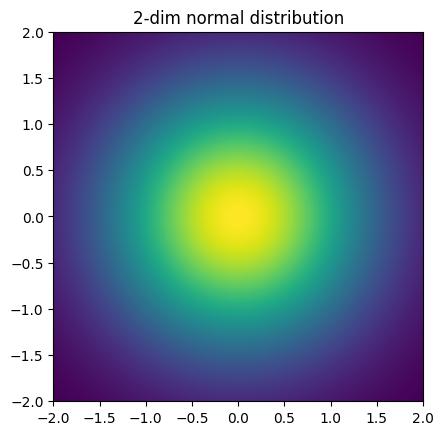

In [2]:
# define dimension of p(x)
dim = 2
# multi normal with u = 0, cov = I
dist = MultivariateNormal(torch.zeros((dim)), torch.eye(dim))

# 2D grid
ls = np.linspace(-2, 2, 1000)
x, y = np.meshgrid(ls, ls)
points = torch.tensor(np.vstack([x.flatten(), y.flatten()]).T)
# log probability (density?)
ps = torch.exp(dist.log_prob(points))

# plot
fig = plt.figure()
ax = fig.add_subplot()
ax.set_title('2-dim normal distribution')
ax.pcolormesh(x, y, ps.reshape(x.shape), cmap='viridis')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
plt.show()

In [3]:
# langevin monte calro
def expanded_rand(expand_rate, num_samples, dim):
    x = torch.rand(num_samples, dim)
    x = x - 0.5
    x = x * 2 * expand_rate
    return x
    
def langevin_monte_calro(dist, num_samples, num_steps, step_size, dim):
    import copy
    # sampling x0 from normal distribution
    #x = torch.randn(num_samples, dim)
    # sampling x0 from uniform distribution
    x = expanded_rand(2, num_samples, dim)
    x0 = copy.deepcopy(x)
    x_path = []
    for i in range(num_steps):
        x.requires_grad_()
        log_p = dist.log_prob(x)
        score = torch.autograd.grad(log_p.sum(), x)[0]
        with torch.no_grad():
            noise = torch.randn(num_samples, dim)
            x = x + step_size * score + np.sqrt(2 * step_size) * noise
            x_path.append(x)
    return x, x0, x_path

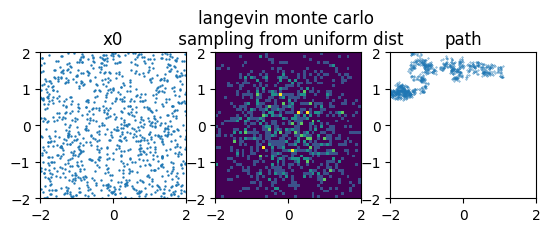

In [13]:
# parameters
num_samples = 1000
num_steps = 1000
step_size = 0.001
dim = 2

samples, x0, x_path = langevin_monte_calro(dist, num_samples, num_steps, step_size, dim)

# plot result (normal distribution should be restored)
fig = plt.figure()
ax0 = fig.add_subplot(1,3,2)
ax0.hist2d(
    samples[:,0],
    samples[:,1],
    range=((-2,2), (-2,2)),
    cmap='viridis',
    bins=50)

ax0.set_title('langevin monte carlo \n sampling from uniform dist')
ax0.set_aspect('equal', adjustable='box')
ax0.set_xlim([-2, 2])
ax0.set_ylim([-2, 2])

ax1 = fig.add_subplot(1,3,1)
ax1.scatter(x0[:,0], x0[:,1], s=0.5)
ax1.set_title('x0')
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim([-2, 2])
ax1.set_ylim([-2, 2])

ax2 = fig.add_subplot(1,3,3)
x_paths = []
for p in x_path:
    x_paths.append(p.detach().numpy()[0])
np_x_paths = np.array(x_paths)
np_x_paths
ax2.scatter(np_x_paths[:, 0], np_x_paths[:, 1], s=0.1)
ax2.set_title('path')
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim([-2,2])
ax2.set_ylim([-2,2])
plt.show()

(-2.0, 2.0)

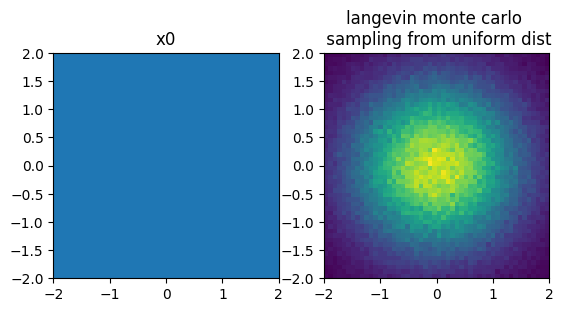

In [17]:
# parameters
num_samples = 500000
num_steps = 1000
step_size = 0.001
dim = 2

samples, x0, x_path = langevin_monte_calro(dist, num_samples, num_steps, step_size, dim)

# plot result (normal distribution should be restored)
fig = plt.figure()
ax0 = fig.add_subplot(1,2,2)
ax0.hist2d(
    samples[:,0],
    samples[:,1],
    range=((-2,2), (-2,2)),
    cmap='viridis',
    bins=50)

ax0.set_title('langevin monte carlo \n sampling from uniform dist')
ax0.set_aspect('equal', adjustable='box')
ax0.set_xlim([-2, 2])
ax0.set_ylim([-2, 2])

ax1 = fig.add_subplot(1,2,1)
ax1.scatter(x0[:,0], x0[:,1], s=0.5)
ax1.set_title('x0')
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim([-2, 2])
ax1.set_ylim([-2, 2])

In [6]:
np_x_paths = np.array(x_paths)
np_x_paths

array([[-1.8891358 , -0.42971566],
       [-1.8316833 , -0.40660617],
       [-1.8613181 , -0.39529723],
       ...,
       [-0.37810627, -0.5634896 ],
       [-0.37298453, -0.56429106],
       [-0.3816816 , -0.5451124 ]], shape=(1000, 2), dtype=float32)

NameError: name 'np_x_path' is not defined

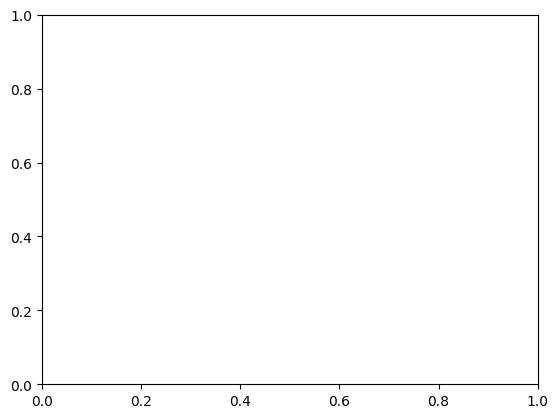

In [7]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(np_x_path[:, 0], np_x_path[:, 1])
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
plt.show()